# **How to access various geospatial data via web APIs**?  

#### This notebook is to train end users of AquaInfra Interactive Platform (AIP) to find and access geospatial data via web API requests from JupterNotebook environment directly.  
Additionally, this notebook gives examples to ease starting of data analysis by users after reading/access different geospatial data types from APIs. The example includes:  
*   calculating distance of point
*   visualizing in interactive maps
*   accessing and analysing data etc

More deeper data analysis is left for subject experts/researcher.

> Authors: Mohammad Imangholiloo and Ville Mäkinen,  Finnish Geospatial Research Institute, National Land Survey of Finland, Espoo, Finland

Please feel free to contact us.

If you are interested to learn more about:
 *   data accessing via API's in Jupyter environments such as Google Colab, please see: https://colab.research.google.com/github/nestauk/im-tutorials/blob/3-ysi-tutorial/notebooks/APIs/API_tutorial.ipynb
*    working with raster and vector files: https://colab.research.google.com/github/worldbank/OpenNightLights/blob/master/onl/tutorials/mod5_3_vector_and_raster_data.ipynb
 *   geopandas for vector: https://colab.research.google.com/github/giswqs/geog-312/blob/main/book/geospatial/geopandas.ipynb  
 *   rasterio for raster: https://colab.research.google.com/github/giswqs/geog-312/blob/main/book/geospatial/rasterio.ipynb  
 *   interactive plotting raster and vector using leafmap in Google colab: https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/dataviz/raster_viz.ipynb  



In [ ]:
#Let us install required packages before start
!pip install leafmap geopandas rasterio rioxarray

### Background
Please visit homepage of AquaInfra Interactive Platform (AIP) on https://aquainfra.dev.52north.org/ and add some keywords in the "Search for research data" bar, e.g. *river*. It will search *like google* for any data among all available data from various data providers listed in right side box. Below screenshot shows it. The search lists all found data and also suggest closest keywords. Please give yourself time to search any data of your interest and feel free to explore it.  


Screenshot of the AIP homepage with the "river" as a search term:  
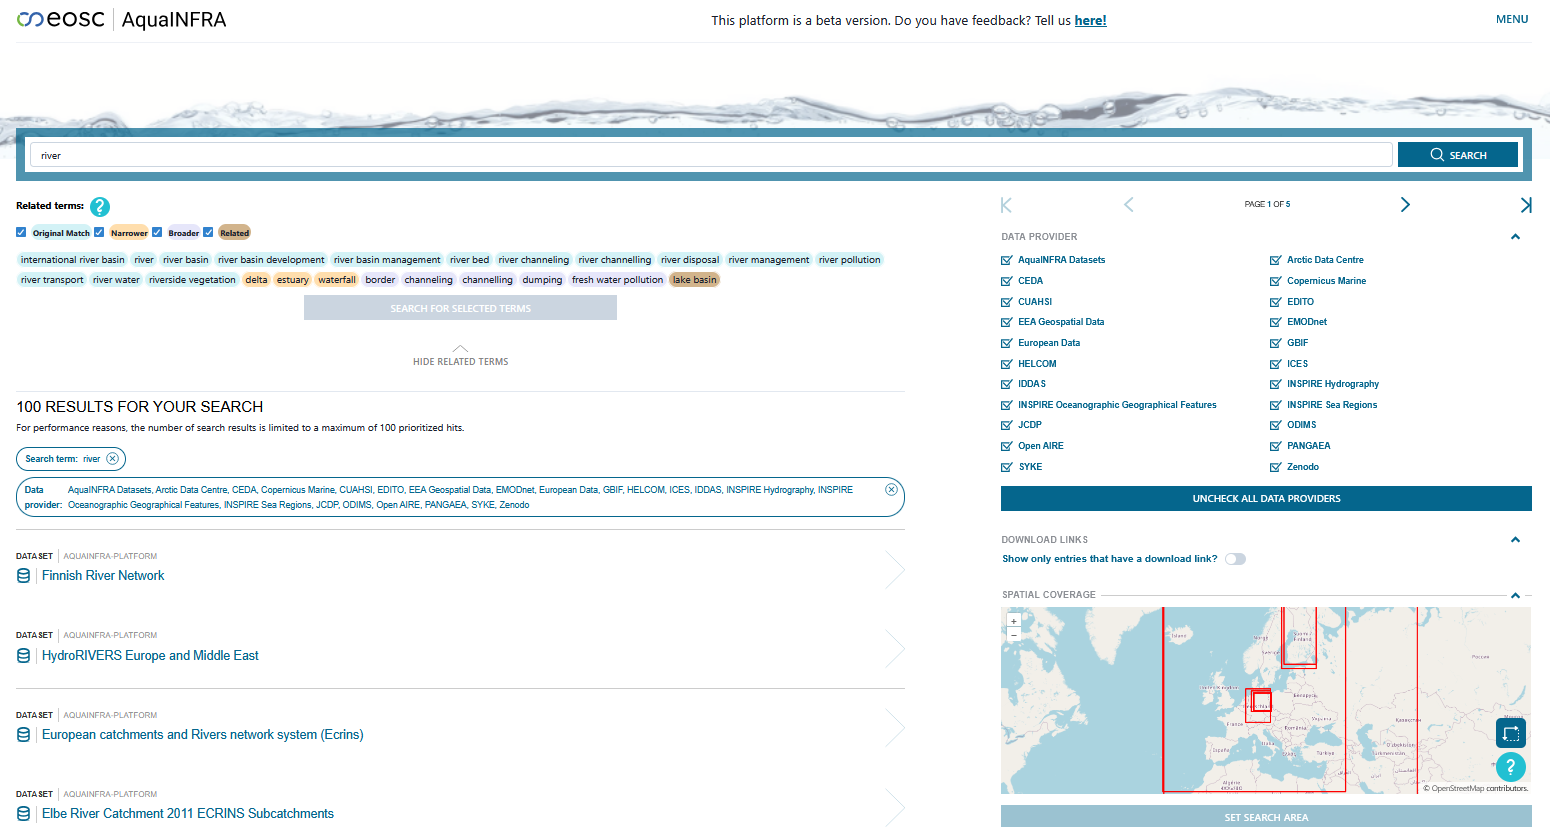

### **General Rules of this notebook**
Here we have examples to provid step-by-step guide for exploring the data and find suitable URL API links for data access here in Jupyter notebook.  

In some places along the Notebook, you will see "**`Task`**:". It means you are expected to read and do that please.

### **Instruction**
On the homepage, search term "*river*". Press search.  
Now, Below the search bar, it listed "*Related terms*" to your keyword and in the right side, you can see list of Data Providers from which the api looked for the term your input.

Now, please scroll down a bit to select: "*Discharge data from automated river stations in Finland*".  Once the new browser tap opened the link, on right side of the page, where is written "*Title: Map view [Discharge]*" press VISIT. Once the new page is opened, on top bar it shows "*OAPIF / Collections / SYKE Discharge / Items*" click on "*SYKE Discharge*" (alternatively, remove "/items?f=html" from end of url), then at the end of page, press "*View*" button. It will show all items on map, within the given bbox on browser.
NOTE: The opening new page or appearace of the items on map may take few second.

Now, you can zoom and freely see the data. On the browser URL, you can change the last number which is 70'sth to 62 to zoom to only southen Finland. Now, copy paste the URL to below cell.

Now, it is time to access the data behind the items. So, continue to next section :)



In [ ]:
url = "https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/fin_sykedischarge/items?bbox=-20.98937264741765,58.52406032052693,72.18937264741764,70.6380822712739"

Your link will look like the above example.  
Let us explain a bit what the url link contains and what each part mean?
Let us first seperate each part by `/` sign in the url.
`https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/fin_sykedischarge/items?bbox=-20.98937264741765,58.52406032052693,72.18937264741764,62`  

So, we can see that:  
1. `https://vm4072.kaj.pouta.csc.fi` which refers the server address  
2. `ddas` refers to what developers gaved name  
3. `oapif/` mean open api feature (feature is OFC term for vector files in desktop GIS world)  
4. `collections` is the pygeoapi collection, which can contain list of items (raster or vectors etc)    
5. `fin_sykedischarge` is the name of item that we would like to explore.    
6. `items` tells that we looking for items inside the upper level item. We can specify which item id we like to explore.  
7. `bbox=-20.98937264741765,58.52406032052693,72.18937264741764,62` referes to bounding box in WGS84 for the area of interest. you can change or limit it. format of bbox is minx, miny, maxx, maxy. Bound box is consisted to minx, miny, maxx, maxy in geographical coordinate system.

## 1.1 **vector data** (e.g. OGC feature)

Now, we can get the data direclty via geopadas or via requests.get. they are both the sam, just alternatives. Let us start getting data via geopandas.

Now let us read it directly via geopandas code: ```gpd.read_file(url)```

In [ ]:
import geopandas as gpd
gdf = gpd.read_file(url)

In [ ]:
gdf.shape

It reads/accesses the data using geopadas library as geopadas dataframe directly from given url. So, this war was the way to access and deliver data from API, from here onwards includes few examples to assist data analysis.  


`**NOTE**`: You may also noticed how amazing it was that we just accessed data directly via API url that we read it as a Python object (called gdf) and is ready for next steps of data analysis. Conventionally, we should have it downloaded locally and stored in your compare, then reading from local data. So, we read them directly via ```gpd.read_file(url)``` in above cell into our Notebook. Amazing 😯

In [ ]:
# Let us see its head(first 3 rows)
gdf.head(3)

In [ ]:
#Let us see the dimention/shape of the read file
gdf.shape

In [ ]:
gdf_21_northFin = gdf

So, in above code, we read 21 item, and each one has 3 columns (as was shown in above cells print)

In [ ]:
#look at the discharge column, show only first 3 rows
gdf["discharge"].head(3)

In above cell, we can see that the discharge value is a list of lists, and each list includes date, time, and discharge value. We can convert them to be ordinary dataframe to continue doing common analysis on it.

In [ ]:
import pandas as pd
# Example of what ONE cell in gdf["data"] looks like:
# [
#   ['2026-01-01T00:00:00', '77.72'],
#   ['2026-01-02T00:00:00', '108.37'],
#   ['2026-01-03T00:00:00', '127.89']
# ]

# ---------------------------------------------------
# 1. Ensure the column really contains Python lists
#    (sometimes it's a string that *looks* like a list)
# ---------------------------------------------------
if isinstance(gdf["discharge"].iloc[0], str):
    gdf["discharge"] = gdf["discharge"].apply(eval)
gdf.head(3)

In [ ]:
# ---------------------------------------------------
# 2. Explode: one [time, value] pair per row
#    This is the key step that prevents "only first value", meaning geopandas.explode slipts
#    each row containing a multi-part geometry (in our case list of [time and discharge values])
#    into multiple rows with single geometries, thereby increasing the vertical size of the GeoDataFrame.
# ---------------------------------------------------
gdf_converted = gdf.explode("discharge", ignore_index=True)
gdf_converted.head(3)

In [ ]:
# ---------------------------------------------------
# 3. Split the pair into two columns
#    Now every row is exactly: ['time', 'value']
# ---------------------------------------------------
gdf_converted[["time", "value"]] = gdf_converted["discharge"].apply(pd.Series)
gdf_converted.head(3)

In [ ]:
# ---------------------------------------------------
# 4. Convert to correct dtypes
# ---------------------------------------------------
gdf_converted["time"] = pd.to_datetime(gdf_converted["time"])
gdf_converted["discharge_value"] = pd.to_numeric(gdf_converted["value"], errors="coerce")
gdf_converted.head(10)

In [ ]:
# ---------------------------------------------------
# 5. ['Optional'] if you wish, drop the original nested column
# ---------------------------------------------------
#gdf = gdf.drop(columns="data")

In [ ]:
gdf_converted

In [ ]:
#select an id in gdf and paste in below line
gdf_converted_id_1351 = gdf_converted[gdf_converted.id == "1351"]
gdf_converted_id_1351
gdf_converted_id_1351.plot.line(x= "time", y= "discharge_value",figsize=(8,2), marker="o")


In [ ]:
# plot all unique id values automatically (instead of manually selecting "1351") in seperate subplots
for uid, subset in gdf_converted.groupby("id"):
    plt.figure(figsize=(8, 2))
    plt.plot(subset["time"], subset["discharge_value"], marker="o")
    plt.title(f"ID: {uid}")
    plt.grid(True)
    plt.show()

In [ ]:
# plot all unique id values automatically (instead of manually selecting "1351") in one big plots

plt.figure(figsize=(15, 4))

for uid in gdf_converted["id"].unique():
    subset = gdf_converted[gdf_converted["id"] == uid]
    plt.plot(subset["time"], subset["discharge_value"], marker="o", label=uid)

plt.xlabel("Time")
plt.ylabel("Discharge Value")
plt.legend(title="ID")
plt.grid(True)
plt.show()

In [ ]:
# plot interactively on leaflet zoomable map
gdf_converted.explore()

In [ ]:
# calculate distance to the first point: i.e. gdf_converted.geometry.iloc[0]
from shapely.ops import nearest_points

# Example: distance to first point
gdf_converted["dist_to_first"] = gdf_converted.geometry.apply(lambda p: p.distance(gdf_converted.geometry.iloc[0]))
gdf_converted

In [ ]:
# Example: distance to a point: i.e. Point(26.7457, 67.96272)
from shapely.geometry import Point

ref_point = Point(26.7457, 67.96272)
gdf_converted["dist_to_point"] = gdf_converted.geometry.distance(ref_point)
gdf_converted.head(3)

In [ ]:
#select only closest 5 points

# sort and select first 5
top5 = gdf_converted.sort_values("dist_to_point", ascending=True).head(5)
top5

In [ ]:
gdf_converted.columns

In [ ]:
gdf_converted.to_file('dataframe_gdf_converted.gpkg', driver='GPKG', layer='name')

In [ ]:
# if you like to subset data of only one specific id, for example id = 1351
gdf_id_1351 = gdf_converted[gdf_converted['id'] == "1351"]
gdf_id_1351.head()

In [ ]:
!ls -l /content/

In [ ]:
# to download to your local machine run the below code OR in left menue, click on Files > find the file and Download
# read more on https://neptune.ai/blog/google-colab-dealing-with-files
from google.colab import files
files.download("/content/dataframe_gdf_converted.gpkg")



> **`Task`**: remove the ?bbox=-20.98937264741765,58.52406032052693,72.18937264741764,62 part from the url and run again. See that changes (e.g. shape of gdf) and why it changes?





> **`Task`**: Try below cell with the given new url. Just uncomment its lines, run and interpret your observations.

In [ ]:
#url_task = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_0_countries.geojson"
#gdf = gpd.read_file(url_task)
#gdf
###exlain what you see.

# plot it via
#gdf.explore()

> **`Task`**: Now that it plotted the countires, calculate areas of each polygon and add area as new column to it. (see below cell)

In [ ]:
# Calculate the area (relevant if it is polygon)
#gdf["area_testing"] = gdf.area
#gdf

> **`Task`**: Now repeat the above task (accessing data, reading it, calculating area of polygons) to this webapi: https://ogcapi.laji.fi/collections/ahvenanmaa_polygons/items


> **`Task`**: [ ADVANCED]. You can get the features within bbox also for example by giving bbox to end of url. For example:   

https://ogcapi.laji.fi/collections/ahvenanmaa_polygons/items
  
  add ```?bbox=20,60,20.01,60.01``` to its end and rerun. See if the shape of gpd changes?

*italicized text*> **`Task`**: Go to this example page (https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/erm_), select one of the items by  clicking on it (e.g. I selected "*EuroRegionalMap Seas*"), then scroll down on new page to see: "*items as GeoJSON (application/geo+json)*". Open that and copy its url to your above codes and try reading and plotting it.
NOTE: Getting data from the urls may take few seconds, so please be patient.

### Alternatively, via requests.get(url)
You can read the data via http requests.get(url).


In [ ]:
import requests
import pprint

# Get collections metadata
response = requests.get(url) ### NOTE: this is the same url from beginning
collections = response.json()
pprint.pprint(collections)

In [ ]:
#accessing the first feature of the collection
collections["features"][1]

It is now read as geojson dictionary (list of features). One can convert it to geopandas df if needed, using the following cell:

In [ ]:
gdf = gpd.GeoDataFrame.from_features(collections['features'], crs="EPSG:4326")

# Extract feature IDs
gdf["feature_id"] = [f.get("id") for f in collections["features"]]

print("The shape (row, column) of the file is =", gdf.shape)
gdf.head()

In [ ]:
gdf.shape

In [ ]:
##################### alternatively #####################
#from shapely.geometry import shape
#gdf2 = gpd.GeoDataFrame(
#    [feature["properties"] for feature in collections["features"]],
#    geometry=[shape(feature["geometry"]) for feature in collections["features"]],
#    crs="EPSG:4326")
#gdf2

### **Advanced part 1:**
You can also put the desired date range to access the data. Now, you can also zoom in to click on one of the items, then its item number will appear on top of menue after "*OAPIF / Collections / SYKE Discharge / Items *" for example it will be 1018. Now the URL will be sth like this: https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/fin_sykedischarge/items/1018
  
Now, you will see on the right side of the page: discharge values, date and values.

Scroll down to see: Links and inside it, see
"*This document as GeoJSON (application/geo+json)*". Now, you can see link that this: https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/fin_sykedischarge/items/1018?f=json
This is basically, the geojson of that file. you can read it like above.


and put dates

In [ ]:
https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/fin_sykedischarge/items/1352

In [ ]:
url_json = "https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/fin_sykedischarge/items/1352?f=json"
gdf = gpd.read_file(url_json)
gdf.head(3)

In [ ]:
gdf.discharge.values

Depending on the input desited dates, you can add it link this:
```
&datetime=2025-10-01T00:00:00Z/2026-01-01T00:00:00Z
```  
to the end of yuor url.

In [ ]:
url_json = "https://vm4072.kaj.pouta.csc.fi/ddas/oapif/collections/fin_sykedischarge/items/1018?f=json&datetime=2025-12-01T00:00:00Z/2026-01-31T00:00:00Z"
gdf_desireddate = gpd.read_file(url_json)
gdf_desireddate.head(3)

In [ ]:
#Now let us see the discharge values
gdf_desireddate.discharge.values

In [ ]:
#convert NumPy array that contains a list of dictionaries to df
df_1 = pd.DataFrame(gdf_desireddate.discharge[0])
df_1.head(3)


In [ ]:
#Checking data type of discharge value
df_1.value.dtype

as it is ```dtype('O')```, we shall convert them to numeric. See below cell.

In [ ]:
#converting data type of discharge value to numeric
df_1['value'] = pd.to_numeric(df_1['value'], errors='coerce')

#getting descriptive statistics of the discharge values using pandas.describe()
df_1.value.describe()

## 1.2 **raster data** (e.g. OGC coverage)

Now, you can put the term "*raster*" in the homepage. select "*Medium Resolution Vegetation Phenology and Productivity: Plant phenology index (raster 500m), Oct. 2022*" then in the righ side select in "*Protocol: image/png*" HOWEVERE, the download links for rasters may be crashing still due to technical reasons (under development). So, for now, please let us use this page:  
https://vm4072.kaj.pouta.csc.fi/ddas
  

Now, click on Access data under "*Raster Access*". It will open https://vm4072.kaj.pouta.csc.fi/ddas/oapic/
oapic means open api for coverage. Coverage is the term used by OGC for rasters.  

Now, under "*Collections*" press "*View the collections in this service*" which is hyperlinked. It shows list of collection. Let use for example select the first one "*CORINE Land Cover Plus [Pseudo Mercator]*". To get acces to the read data on Jupyter notebook, scroll down to the buttom of page where you see "*Coverage data as GTiff (image/tiff)*". With your mouse, right click and copy link. It will be: https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clcplus3857/coverage?f=GTiff. Now it is our url for raster. paste it to next cell and lets continue.


-20.98937264741765,58.52406032052693,72.18937264741764,70.6380822712739

In [ ]:
https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?subset=x(-5158532.244133477:7158943.493688605),y(3600720.848604912:12398917.804192113)&f=html

In [ ]:
url = 'https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff&subset=x(0:7158943.493688605),y(9600720.848604912:12398917.804192113)&scale-size=x(514.4000000000001),y(798.4000000000001)'

####  NEW today:  Discharge data from automated river stations in Finland > AquaINFRA Datasets  > Hydrography90m Basin [Pseudo Mercator]
#https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/h90m_basin3857/coverage?f=html


Now, it is time to read the raster from API to our jupyter notebook via rasterio directly.

In [ ]:
import rasterio
from rasterio.plot import show
raster = rasterio.open(url) #, masked=True

print("rasters statsictal metadata is:", raster.meta)

In [ ]:
# we can show the raster:
show(raster)

In [ ]:
#if you like to read specific band
#raster2 = raster.read(1, masked=True)

In [ ]:
#bound box of raster
raster.bounds

### `TIP`: it is possible to read raster via gdal directly from url api too. See below:

In [ ]:
#!apt-get update -qq
#!apt-get install -y gdal-bin python3-gdal

In [ ]:
from osgeo import gdal
print(gdal.VersionInfo())

In [ ]:
ds = gdal.Open(url)

print(ds.GetProjection())
print(ds.GetGeoTransform())
print(ds.RasterXSize, ds.RasterYSize)

In [ ]:
import numpy as np
band = ds.GetRasterBand(1)
nodata = band.GetNoDataValue()

arr = band.ReadAsArray()
arr = np.ma.masked_equal(arr, nodata)

In [ ]:
#our rasters cooridiate refeence sytem
raster.crs

In [ ]:
#shap/dimentions of raster
raster.shape

In [ ]:
ds.RasterXSize

In [ ]:
#no data of raster
raster.nodata

In [ ]:
#Few statisitcs of the raster's pixel values, e.g. min, max, mean, standard deviation
raster.statistics(1) #to do stats on band 1

Now we can plot the raster on leafmap interactive plot.  
Please zoom out to see the raster. Showing it may take few seconds, please be patient.

In [ ]:
import leafmap
m = leafmap.Map()
m.add_cog_layer(url, name="Corine Land cover")
m

In [ ]:
# Let us replot and show location of plots (Section 1.1)
gdf_converted.explore()

In [ ]:
#Percentiles
#percentiles = np.percentile(values, [25, 50, 75, 90])
#print("25%, 50%, 75%, 90% percentiles:", percentiles)

### Advanced part 2: get pixel values overlayed with vector file (discharge data) as new column, and save it.

In [ ]:
raster.crs

In [ ]:
gdf_21_northFin.crs #gdf_converted.crs

In [ ]:
#Reprojecting crs of points to that of raster's crs
gdf_converted_reproj = gdf_21_northFin.to_crs(raster.crs)

In [ ]:
#double checking if now their crs is the same
raster.crs == gdf_converted_reproj.crs

In [ ]:
#Sample raster values at points
#Rasterio provides sample() for this:


# Create list of point coordinates as [(x, y), ...]
coords = [(point.x, point.y) for point in gdf_converted_reproj.geometry]

# Sample raster at each coordinate
values = [val[0] for val in raster.sample(coords)]  # val is a list per band

# Assign to GeoDataFrame
gdf_converted_reproj["raster_value"] = values

gdf_converted_reproj.head(3)

In [ ]:
gdf_converted_reproj

In [ ]:
#dropping those points which did not overlap with sample points, so their raster_value is 255 (no data)
gdf_converted_reproj_includedpoints= gdf_converted_reproj[gdf_converted_reproj.raster_value != 255]

In [ ]:
gdf_converted_reproj_includedpoints.head(3)

In [ ]:
#from google.colab import sheets
#sheet = sheets.InteractiveSheet(df=gdf_converted_reproj_includedpoints)

In [ ]:
gdf_converted_reproj_includedpoints.groupby(by= "raster_value").count()

In [ ]:
gdf_converted_reproj_includedpoints.raster_value.hist(bins=256)

### Advanced part 3:
You can read the collection s a whole and select things by adding things to the end of url. See below

In [ ]:
# List all collections
import requests

base_url = "https://vm4072.kaj.pouta.csc.fi/ddas/oapic"

r = requests.get(f"{base_url}/collections")
collections = r.json()

for c in collections["collections"]:
    print(c["id"], "-", c["title"])


now, if you put the first part of name (before - ) in collection_id it can direclty read that.

In [ ]:
collection_id = "h90m_basin4326"
base_url = "https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/h90m_basin4326/coverage?subset=x(0:4.30988358528478),y(60.75306162442881:73.70866809709719)"
#r = requests.get(base_url) ##(f"{base_url}/collections/{collection_id}")

#IF the url is vector data uncomment the following lines
#response = requests.get(base_url)
#collections = response.json()
#pprint.pprint(collections)

#IF the url is for raster data, run the following line.
#my_raster = rasterio.open(base_url)


> **`Task`**: Now, try other item from the collection (https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections) and repeat above steps on it.

**Note**: some coleections may be links to other collection of items, if so, again select one of them until you find the "*Coverage data as GTiff (image/tiff)*" from bottum of the page. copy paste the link as new url and repeat the above steps.  
* Explain your reflection.   
* Do you find it any useful at all compared to using local data?

 ## 1.3. **metadata** (e.g. OGC records)

In [ ]:
import requests  # Import the requests library

# Query URL
url = "https://vm4072.kaj.pouta.csc.fi/ddas/oapir/collections/copernicusmarine/items"
# Some api's will have nicer syntax like:
# `&time=2010..2012` or `&na_item=B1GQ,D21`
print(url)

response = requests.get(url)  # Make a GET request to the URL

# Print status code (and associated text)
print(f"Request returned {response.status_code} : '{response.reason}'")

# Print data returned (parsing as JSON)
payload = response.json()  # Parse `response.text` into JSON

import pprint
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(payload)
# NOTE: Could use print(response.json()) but this wouldn't be formatted nicely

In [ ]:
# see the metadata of first feature (item)
payload['features'][0]

In [ ]:
item_name = payload['features'][0]["id"]
url = url+"/"+item_name
print(url)

In [ ]:
response = requests.get(url)  # Make a GET request to the URL

# Print status code (and associated text)
print(f"Request returned {response.status_code} : '{response.reason}'")

# Print data returned (parsing as JSON)
payload = response.json()  # Parse `response.text` into JSON

import pprint
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(payload)


### Advanced part 4: getting data within an spatial box or subset:
In PyGeoApi, you can give bbox or subset of our area of interest, and it returns only that partm instead of reading (requesting) the whole data. All you need is to give bbox or subset as following to the end of url:  
```
&bbox=24,60,25,61
```  
if needed also add the crs of bbox```&bbox-crs=3857```  
For example in case of this example url:  

```  
https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff
```  
we can add

```
&bbox=24,60,25,61
```

so it will be


```
https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff&bbox=24,60,25,61
```
and it will download that subset of the data via url requests.  

As you can see, the file size (when downloading) is smaller now, becuase we request subset of the data.  


---
---
> Another example:

Another example can be the url that we were working already in our code above, which was:

```
https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff
```
we can add

```
&subset=x(3034143:3035143),y(8782089:8792089)&scale-size=x(1000),y(1000)
```

so it will be


```
https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff&&subset=x(3034143:3035143),y(8782089:8792089)&scale-size=x(1000),y(1000)
```
which finally will give you that subset of spatial area, with pixels scaled to 1000.
> subset x (xmin to xmax)  y (ymin to ymax).
> scale-size is the output pixels size. Do not make it so small pixel size for large areas. Server has specifications to avoid too large requests.


Please read more examples in https://docs.pygeoapi.io/en/latest/publishing/ogcapi-coverages.html#data-access-examples

In [ ]:
import rasterio
url_with_bbox = "https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff&&subset=x(3033143:3034143),y(8782089:8783089)&scale-size=x(1000),y(1000)"
raster_with_bbox = rasterio.open(url_with_bbox)

In [ ]:
import matplotlib.pyplot as plt
show(raster_with_bbox)

In [ ]:
import leafmap
m = leafmap.Map()
m.add_cog_layer(url_with_bbox, name="Corine Land cover")
#m.zoom_to_bounds(raster_with_bbox.bounds)
m

In [ ]:
with rasterio.open(url_with_bbox) as ds:
    raster = ds.read(1)  # read first band
    transform = ds.transform
    crs = ds.crs

In [ ]:
import numpy as np

# Mask nodata values if they exist
if ds.nodata is not None:
    raster = np.ma.masked_equal(raster, ds.nodata)

# Compute histogram
hist, bin_edges = np.histogram(raster.compressed(), bins=256)  # compressed() removes masked nodata

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot raster
show(raster_with_bbox, ax=ax1, cmap='viridis')
ax1.set_title("Raster")

# Plot histogram
ax2.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='gray', edgecolor='black')
ax2.set_title("Histogram of pixel values")
ax2.set_xlabel("Pixel value")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
##### bbox in GTiff NEW NEW

url = 'https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff'


params = {
    "bbox": "2600000,8800000,3000000,9000000",  # minx,miny,maxx,maxy
    #"bbox-crs": "http://www.opengis.net/def/crs/EPSG/0/4326",
    #"f": "GTiff"
}

r = requests.get(url, params=params)

with open("output.tif", "wb") as f:
    f.write(r.content)

In [ ]:
x = requests.get("https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/h90m_segment4326/coverage?subset=x(-46.33988358528477:64.30988358528478),y(30.75306162442881:73.70866809709719)")

In [ ]:
!ls -l

## ***1.4 [bonus] Other useful info***
This section is meant just ofr extra bonus. Doing it is just optional.

### 1.4.1 reading webmapservice (WMS)

In [ ]:
import requests

wms_url = 'https://vm4072.kaj.pouta.csc.fi/ddas/oapic/collections/clc_clcplus3857-2018/coverage?f=GTiff&subset=x(-5158532.244133477:7158943.493688605),y(3600720.848604912:12398917.804192113)&scale-size=x(514.4000000000001),y(798.4000000000001)'


r = requests.get(wms_url, timeout=30)

print("status:", r.status_code)
print("content-type:", r.headers.get("Content-Type"))
print(r.text[:300])

In [ ]:
from owslib.wms import WebMapService

wms = WebMapService(wms_url, version="1.3.0")
print(list(wms.contents))


In [ ]:
from rasterio import MemoryFile
from rasterio.plot import show

request = wms.getmap(
    #layers=['CGS_S2_RADIOMETRY'],
    #srs='EPSG:3857',
    #format='image/png',
    bbox=(556945.9710290054,6657998.9149440415,575290.8578174476,6663655.255037144),
    #size=(1920,592),
    #time='2020-06-01'
)

with MemoryFile(request) as memfile:
     with memfile.open() as dataset:
            show(dataset)

### 1.4.2 applying filters in geopandas gdf

In [ ]:
# Remove bad geometries if needed
gdf = gdf[gdf.geometry.notnull()]
gdf = gdf[gdf.is_valid]
gdf = gdf[~gdf.geometry.is_empty]

# Print bounds
print("Bounds:", gdf.total_bounds)

### 1.4.3. Loading data from local zip directly via geopandas

In [ ]:
## FYI: you can load ZIP files that contain your locla data also directly via geopandas:
##zipfile = "zip:///path/to/your/files/example.zip"
##file = geopandas.read_file(zipfile)

In [ ]:
### FYI: plotting other api's raster interactively and directly on leafmap
#m = leafmap.Map()
#url = "https://opendata.digitalglobe.com/events/california-fire-2020/pre-event/2018-02-16/pine-gulch-fire20/1030010076004E00.tif"
#m.add_cog_layer(url, name="Fire (pre-event)")
#m